<a href="https://colab.research.google.com/github/Ganzadidier/Malaria-Diagnosis-CNN-Transfer-Learning/blob/Master/Advancedc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.19.0


'/device:GPU:0'

## Populating namespaces

In [ ]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [ ]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [ ]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-05 15:37:39--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.32, 3.167.192.111, 3.167.192.56, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.32|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   302MB/s    in 1.1s    

2025-10-05 15:37:40 (302 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


In [ ]:
import os
import shutil
from pathlib import Path
import random
from tqdm import tqdm

# ================================
# 1️⃣ Setup Paths
# ================================
source_dir = "cell_images"
output_base = "cell_images_split"

# Split ratios (train: 70%, val: 15%, test: 15%)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Set seed for reproducibility
random.seed(42)

# ================================
# 2️⃣ Create Directory Structure
# ================================
print("Creating directory structure...")

splits = ['train', 'val', 'test']
for split in splits:
    for class_name in ['Parasitized', 'Uninfected']:
        split_dir = os.path.join(output_base, split, class_name)
        os.makedirs(split_dir, exist_ok=True)

print(f"✓ Created directories in '{output_base}/'")

# ================================
# 3️⃣ Split and Copy Files
# ================================
print("\nSplitting and copying files...")

class_stats = {}

for class_name in ['Parasitized', 'Uninfected']:
    source_class_dir = os.path.join(source_dir, class_name)

    # Get all image files
    all_files = [f for f in os.listdir(source_class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Shuffle files
    random.shuffle(all_files)

    total_files = len(all_files)
    train_split = int(total_files * TRAIN_RATIO)
    val_split = int(total_files * (TRAIN_RATIO + VAL_RATIO))

    # Split files
    train_files = all_files[:train_split]
    val_files = all_files[train_split:val_split]
    test_files = all_files[val_split:]

    # Copy files to respective directories
    print(f"\nProcessing '{class_name}':")
    print(f"  Total: {total_files}")
    print(f"  Train: {len(train_files)}")
    print(f"  Val:   {len(val_files)}")
    print(f"  Test:  {len(test_files)}")

    # Copy train files
    for filename in tqdm(train_files, desc=f"  Copying train {class_name}"):
        src = os.path.join(source_class_dir, filename)
        dst = os.path.join(output_base, 'train', class_name, filename)
        shutil.copy2(src, dst)

    # Copy val files
    for filename in tqdm(val_files, desc=f"  Copying val {class_name}"):
        src = os.path.join(source_class_dir, filename)
        dst = os.path.join(output_base, 'val', class_name, filename)
        shutil.copy2(src, dst)

    # Copy test files
    for filename in tqdm(test_files, desc=f"  Copying test {class_name}"):
        src = os.path.join(source_class_dir, filename)
        dst = os.path.join(output_base, 'test', class_name, filename)
        shutil.copy2(src, dst)

    class_stats[class_name] = {
        'total': total_files,
        'train': len(train_files),
        'val': len(val_files),
        'test': len(test_files)
    }

# ================================
# 4️⃣ Print Summary
# ================================
print("\n" + "="*60)
print("SPLIT SUMMARY")
print("="*60)

for class_name, stats in class_stats.items():
    print(f"\n{class_name}:")
    print(f"  Total:  {stats['total']:,}")
    print(f"  Train:  {stats['train']:,} ({stats['train']/stats['total']*100:.1f}%)")
    print(f"  Val:    {stats['val']:,} ({stats['val']/stats['total']*100:.1f}%)")
    print(f"  Test:   {stats['test']:,} ({stats['test']/stats['total']*100:.1f}%)")

total_all = sum(s['total'] for s in class_stats.values())
total_train = sum(s['train'] for s in class_stats.values())
total_val = sum(s['val'] for s in class_stats.values())
total_test = sum(s['test'] for s in class_stats.values())

print(f"\nOverall:")
print(f"  Total:  {total_all:,}")
print(f"  Train:  {total_train:,} ({total_train/total_all*100:.1f}%)")
print(f"  Val:    {total_val:,} ({total_val/total_all*100:.1f}%)")
print(f"  Test:   {total_test:,} ({total_test/total_all*100:.1f}%)")

print("\n" + "="*60)
print("✓ Dataset split complete!")
print(f"✓ Files saved in: {output_base}/")
print("\n📁 Directory structure:")
print(f"  {output_base}/")
print(f"  ├── train/")
print(f"  │   ├── Parasitized/")
print(f"  │   └── Uninfected/")
print(f"  ├── val/")
print(f"  │   ├── Parasitized/")
print(f"  │   └── Uninfected/")
print(f"  └── test/")
print(f"      ├── Parasitized/")
print(f"      └── Uninfected/")
print("="*60)

Creating directory structure...
✓ Created directories in 'cell_images_split/'

Splitting and copying files...

Processing 'Parasitized':
  Total: 13779
  Train: 9645
  Val:   2067
  Test:  2067


  Copying test Parasitized: 100%|██████████| 2067/2067 [00:00<00:00, 8933.35it/s]



Processing 'Uninfected':
  Total: 13779
  Train: 9645
  Val:   2067
  Test:  2067


  Copying test Uninfected: 100%|██████████| 2067/2067 [00:00<00:00, 7007.24it/s]


SPLIT SUMMARY

Parasitized:
  Total:  13,779
  Train:  9,645 (70.0%)
  Val:    2,067 (15.0%)
  Test:   2,067 (15.0%)

Uninfected:
  Total:  13,779
  Train:  9,645 (70.0%)
  Val:    2,067 (15.0%)
  Test:   2,067 (15.0%)

Overall:
  Total:  27,558
  Train:  19,290 (70.0%)
  Val:    4,134 (15.0%)
  Test:   4,134 (15.0%)

✓ Dataset split complete!
✓ Files saved in: cell_images_split/

📁 Directory structure:
  cell_images_split/
  ├── train/
  │   ├── Parasitized/
  │   └── Uninfected/
  ├── val/
  │   ├── Parasitized/
  │   └── Uninfected/
  └── test/
      ├── Parasitized/
      └── Uninfected/


## Advanced CNN with 2 Experiments  (No Data Augmentation)

Found 19290 files belonging to 2 classes.
Found 4134 files belonging to 2 classes.
Found 4134 files belonging to 2 classes.
Classes: ['Parasitized', 'Uninfected']

DATA VALIDATION

📊 Dataset Sizes:
  Training:   19,290 images
  Validation: 4,134 images
  Test:       4,134 images

📊 Class Distribution:

Train:
  Parasitized: 9,645 (50.0%)
  Uninfected: 9,645 (50.0%)

Val:
  Parasitized: 2,067 (50.0%)
  Uninfected: 2,067 (50.0%)

Test:
  Parasitized: 2,067 (50.0%)
  Uninfected: 2,067 (50.0%)


EXPERIMENT: CNN_Exp1_Standard
Config:
  Dropout: 0.5
  L2 Reg:  0.01
  Filters: 1.0x
  LR:      0.0001

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training CNN_Exp1_Standard...
Epoch 1/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6160 - auc: 0.6621 - loss: 9.9859
Epoch 1: val_accuracy improved from -inf to 0.60377, saving model to CNN_Exp1_Standard_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.6161 - auc: 0.6622 - loss: 9.9847 - val_accuracy: 0.6038 - val_auc: 0.8890 - val_loss: 8.3138 - learning_rate: 1.0000e-04
Epoch 2/15
602/603 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7989 - auc: 0.8646 - loss: 7.2135
Epoch 2: val_accuracy improved from 0.60377 to 0.70972, saving model to CNN_Exp1_Standard_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 74s 66ms/step - accuracy: 0.7990 - auc: 0.8647 - loss: 7.2114 - val_accuracy: 0.7097 - val_auc: 0.9435 - val_loss: 5.9688 - learning_rate: 1.0000e-04
Epoch 3/15
602/603 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8705 - auc: 0.9224 - loss: 4.9943
Epoch 3: val_accuracy improved from 0.70972 to 0.74117, saving model to CNN_Exp1_Standard_best_mo

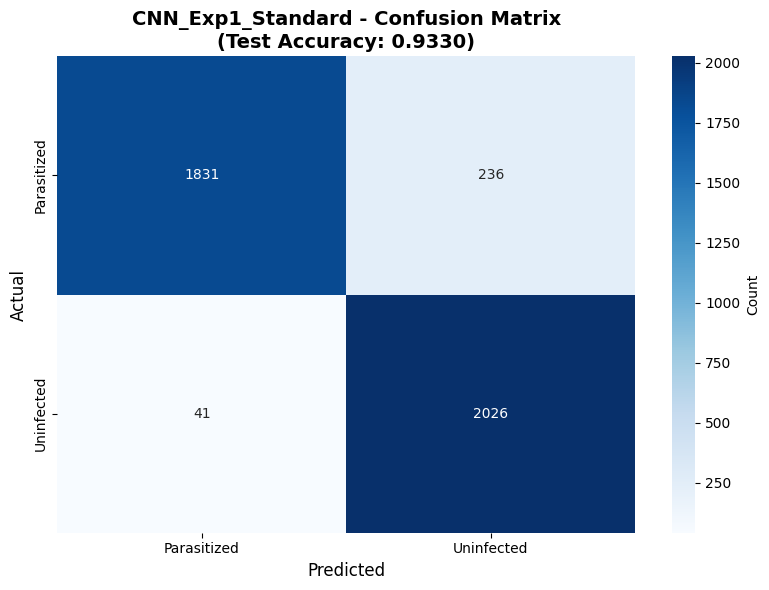

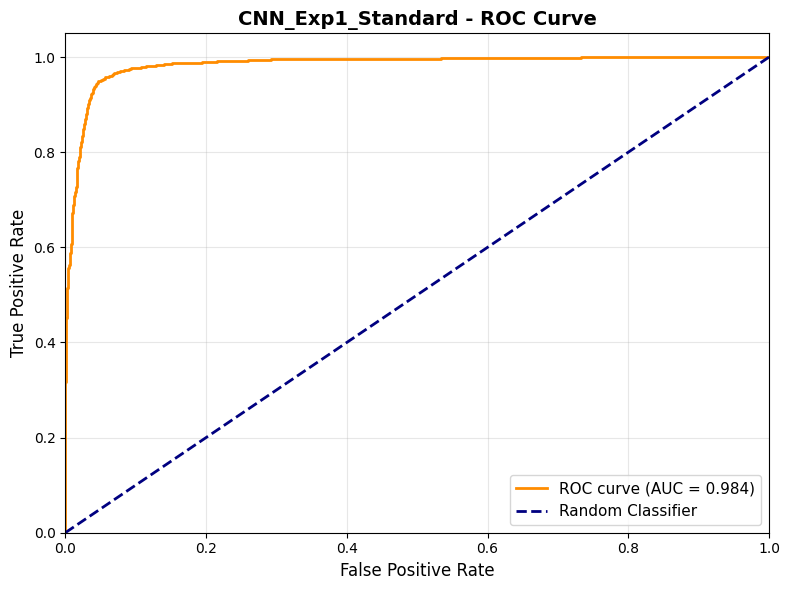

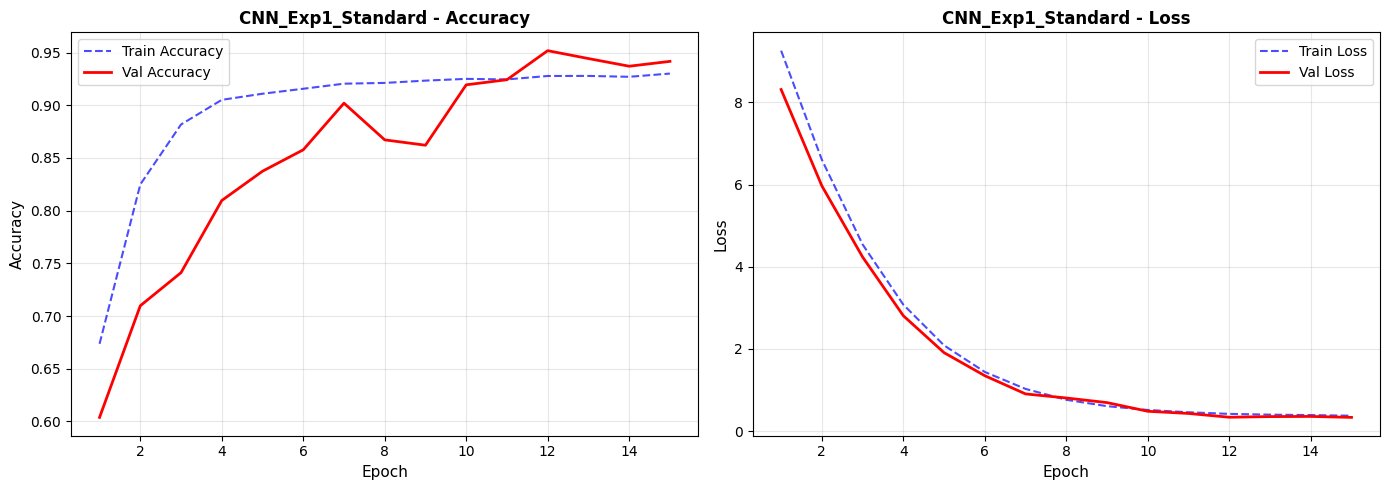


EXPERIMENT: CNN_Exp2_HighRegularization
Config:
  Dropout: 0.6
  L2 Reg:  0.02
  Filters: 0.75x
  LR:      0.0001

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 24)   │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 192)    │       166,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,400,209 (12.97 MB)

 Trainable params: 3,398,977 (12.97 MB)

 Non-trainable params: 1,232 (4.81 KB)


Training CNN_Exp2_HighRegularization...
Epoch 1/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5639 - auc: 0.5852 - loss: 17.2409
Epoch 1: val_accuracy improved from -inf to 0.65312, saving model to CNN_Exp2_HighRegularization_best_model.keras
603/603 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.5639 - auc: 0.5853 - loss: 17.2381 - val_accuracy: 0.6531 - val_auc: 0.8275 - val_loss: 12.4101 - learning_rate: 1.0000e-04
Epoch 2/15
602/603 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7144 - auc: 0.7809 - loss: 11.1247
Epoch 2: val_accuracy did not improve from 0.65312
603/603 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.7145 - auc: 0.7810 - loss: 11.1208 - val_accuracy: 0.6122 - val_auc: 0.9165 - val_loss: 8.2663 - learning_rate: 1.0000e-04
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8012 - auc: 0.8739 - loss: 6.8948
Epoch 3: val_accuracy improved from 0.65312 to 0.73972, saving model to CNN_Exp2_HighRegularization_best_model.keras
603/603 ━━━

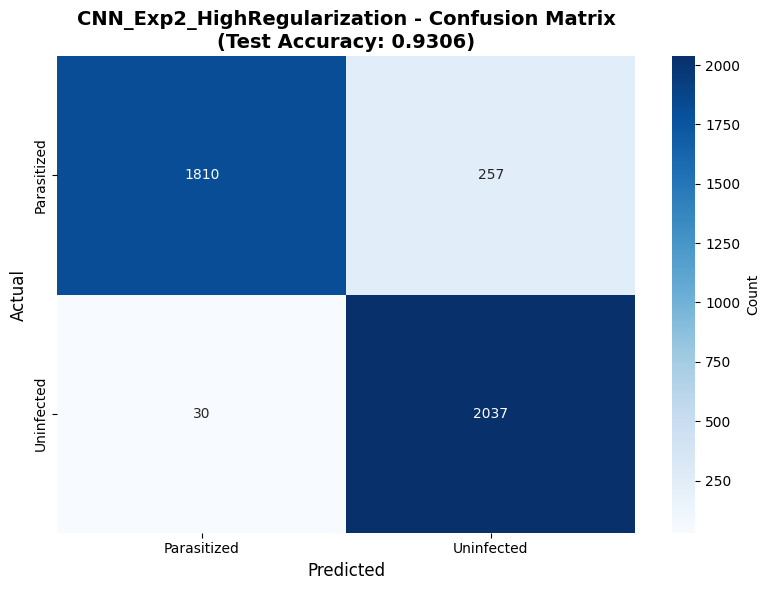

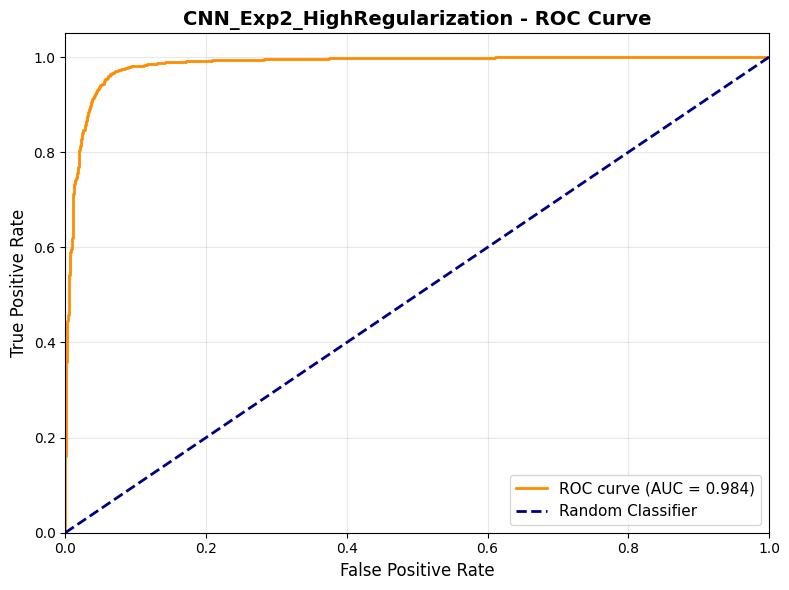

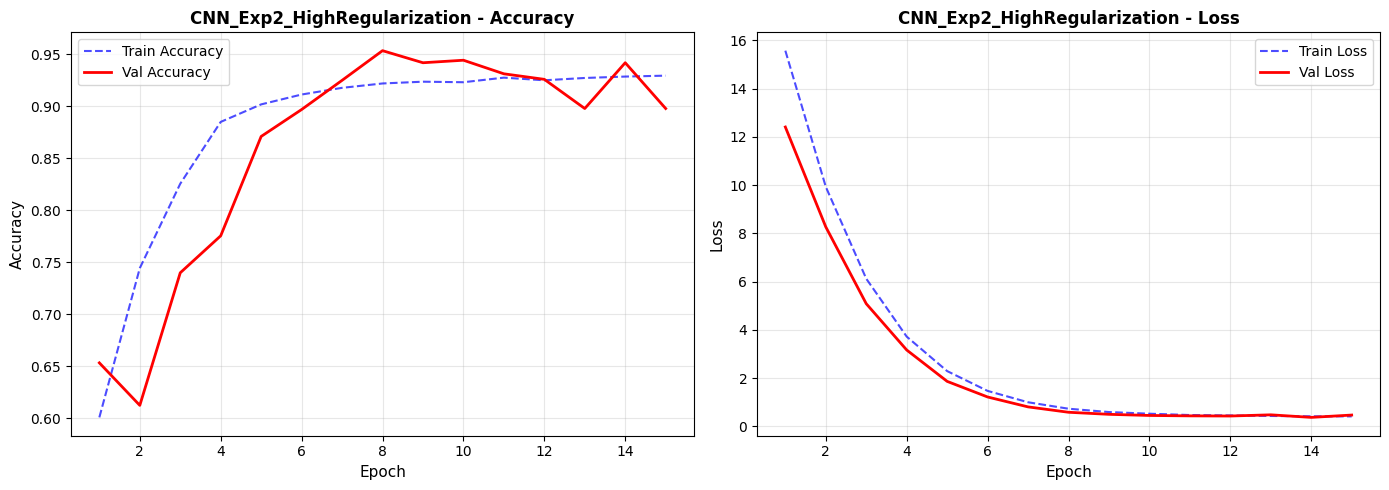


GENERATING COMPARISON PLOTS


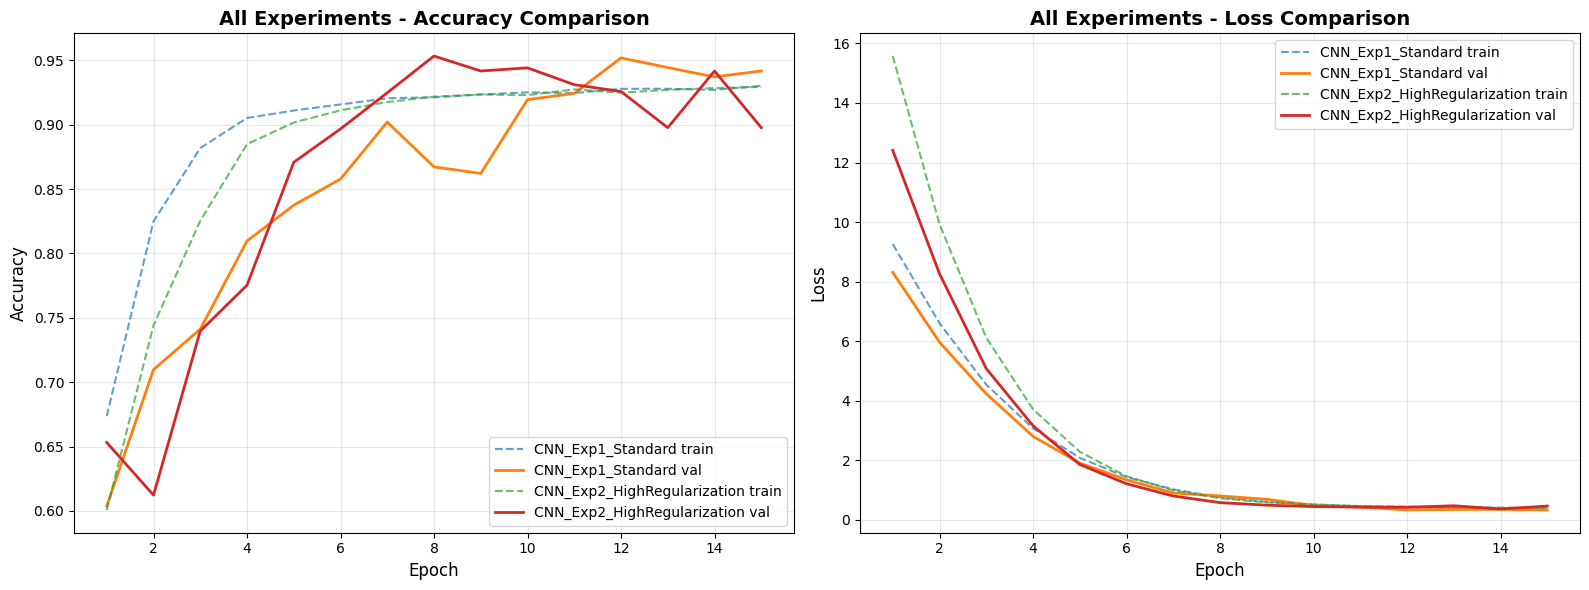


FINAL RESULTS COMPARISON
                 Experiment  Test_Accuracy  Train_Accuracy  Val_Accuracy  Overfitting_Gap  Precision_Parasitized  Recall_Parasitized  F1_Parasitized      AUC
          CNN_Exp1_Standard       0.932995        0.930119      0.941703        -0.011584               0.895668            0.980164        0.936013 0.968805
CNN_Exp2_HighRegularization       0.930576        0.929290      0.897678         0.031612               0.887969            0.985486        0.934189 0.965697

🏆 BEST MODEL: CNN_Exp1_Standard
   Test Accuracy:      0.9330
   Val Accuracy:       0.9417
   Overfitting Gap:    -0.0116
   F1 Score:           0.9360
   AUC:                0.9688


/tmp/ipython-input-3165401372.py:449: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(results_df['Experiment'], rotation=15, ha='right')


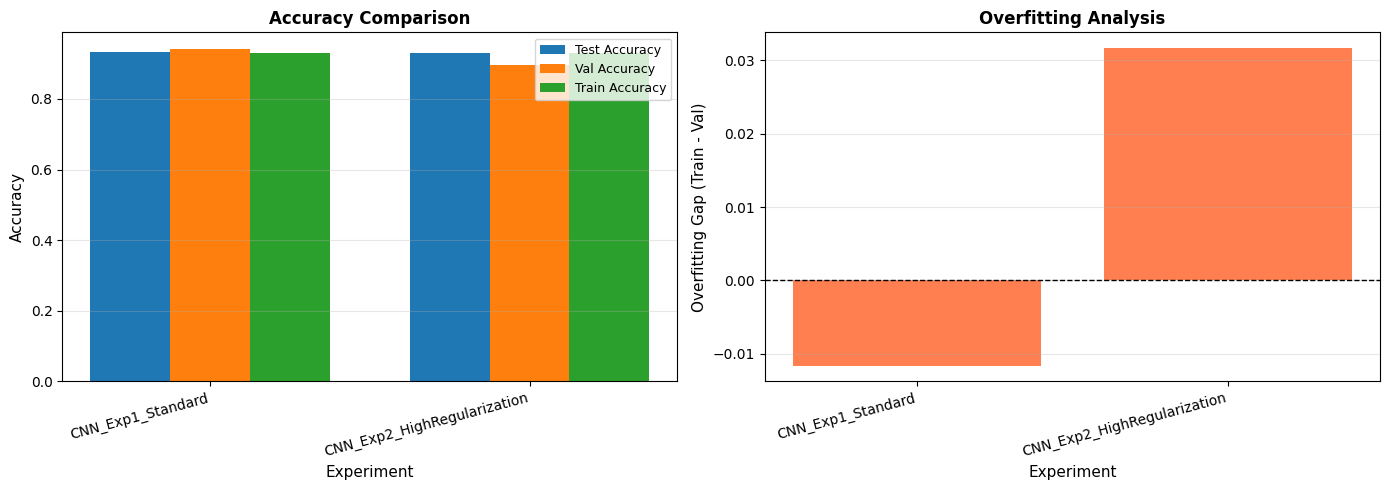


✅ All experiments completed successfully!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import json

# ================================
# 1️⃣ Dataset Loading (From Split Directories)
# ================================
img_size = (128, 128)
batch_size = 32

# Load from the properly split directories
train_ds = image_dataset_from_directory(
    "cell_images_split/train",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

val_ds = image_dataset_from_directory(
    "cell_images_split/val",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    "cell_images_split/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Save class names before prefetching
class_names = train_ds.class_names
print("Classes:", class_names)

# ================================
# 2️⃣ Data Validation
# ================================
print("\n" + "="*60)
print("DATA VALIDATION")
print("="*60)

train_labels = np.concatenate([y for x, y in train_ds], axis=0)
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
test_labels = np.concatenate([y for x, y in test_ds], axis=0)

print(f"\n📊 Dataset Sizes:")
print(f"  Training:   {len(train_labels):,} images")
print(f"  Validation: {len(val_labels):,} images")
print(f"  Test:       {len(test_labels):,} images")

print(f"\n📊 Class Distribution:")
for split_name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    print(f"\n{split_name}:")
    for i, class_name in enumerate(class_names):
        count = np.sum(labels == i)
        print(f"  {class_name}: {count:,} ({count/len(labels)*100:.1f}%)")

print("\n" + "="*60)

# ================================
# 3️⃣ Data Augmentation
# ================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.2, 0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")

# ================================
# 4️⃣ Build Advanced CNN Models
# ================================
def build_advanced_cnn_binary(input_shape=(128, 128, 3), dropout_rate=0.5, l2_reg=0.01,
                              filters_multiplier=1.0, learning_rate=0.0001):
    """
    Build Advanced CNN with configurable regularization

    Args:
        input_shape: Input image shape
        dropout_rate: Dropout rate for regularization
        l2_reg: L2 regularization strength
        filters_multiplier: Multiply filter counts (for lighter/heavier models)
        learning_rate: Learning rate for optimizer
    """
    model = models.Sequential([
        data_augmentation,

        # Block 1
        layers.Conv2D(int(32 * filters_multiplier), (3, 3), activation='relu',
                     padding='same', input_shape=input_shape,
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate * 0.25),  # Light dropout early

        # Block 2
        layers.Conv2D(int(64 * filters_multiplier), (3, 3), activation='relu',
                     padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate * 0.35),

        # Block 3
        layers.Conv2D(int(128 * filters_multiplier), (3, 3), activation='relu',
                     padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate * 0.5),

        # Block 4
        layers.Conv2D(int(256 * filters_multiplier), (3, 3), activation='relu',
                     padding='same',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dropout_rate * 0.6),

        # Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate * 0.5),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ================================
# 5️⃣ Prefetch for Performance
# ================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# ================================
# 6️⃣ Experiment Configurations
# ================================
experiments = [
    {
        "name": "CNN_Exp1_Standard",
        "dropout_rate": 0.5,
        "l2_reg": 0.01,
        "filters_multiplier": 1.0,
        "learning_rate": 0.0001,
        "epochs": 15
    },
    {
        "name": "CNN_Exp2_HighRegularization",
        "dropout_rate": 0.6,
        "l2_reg": 0.02,
        "filters_multiplier": 0.75,  # Lighter model
        "learning_rate": 0.0001,
        "epochs": 15
    }
]

results = []
histories = []

def save_clean_history(history, filename):
    clean_history = {key: [float(v) for v in values]
                     for key, values in history.history.items()}
    with open(filename, 'w') as f:
        json.dump(clean_history, f, indent=4)

# ================================
# 7️⃣ Training & Evaluation Loop
# ================================
for exp in experiments:
    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {exp['name']}")
    print(f"{'='*60}")
    print(f"Config:")
    print(f"  Dropout: {exp['dropout_rate']}")
    print(f"  L2 Reg:  {exp['l2_reg']}")
    print(f"  Filters: {exp['filters_multiplier']}x")
    print(f"  LR:      {exp['learning_rate']}")

    # Build model
    model = build_advanced_cnn_binary(
        input_shape=img_size + (3,),
        dropout_rate=exp['dropout_rate'],
        l2_reg=exp['l2_reg'],
        filters_multiplier=exp['filters_multiplier'],
        learning_rate=exp['learning_rate']
    )

    print(f"\nModel Summary:")
    model.summary()

    # Callbacks
    callbacks = [
        ModelCheckpoint(
            f"{exp['name']}_best_model.keras",
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=4,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # Train
    print(f"\nTraining {exp['name']}...")
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=exp['epochs'],
        callbacks=callbacks,
        verbose=1
    )

    histories.append((exp['name'], history))
    save_clean_history(history, f"{exp['name']}_history.json")

    # ================================
    # Evaluation on Test Set
    # ================================
    print(f"\n{'='*60}")
    print(f"EVALUATION: {exp['name']}")
    print(f"{'='*60}")

    # Get fresh test labels
    y_true = np.concatenate([y for x, y in image_dataset_from_directory(
        "cell_images_split/test",
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False
    )], axis=0)

    # Predictions
    y_pred_probs = model.predict(test_ds, verbose=0)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()

    # Classification Report
    print("\nClassification Report:")
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Metrics
    accuracy = report['accuracy']
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    overfit_gap = final_train_acc - final_val_acc

    print(f"\n📊 Performance Summary:")
    print(f"  Test Accuracy:       {accuracy:.4f}")
    print(f"  Final Train Acc:     {final_train_acc:.4f}")
    print(f"  Final Val Acc:       {final_val_acc:.4f}")
    print(f"  Overfitting Gap:     {overfit_gap:.4f}")

    # Store results
    results.append({
        "Experiment": exp['name'],
        "Test_Accuracy": float(accuracy),
        "Train_Accuracy": float(final_train_acc),
        "Val_Accuracy": float(final_val_acc),
        "Overfitting_Gap": float(overfit_gap),
        "Precision_Parasitized": float(report[class_names[1]]['precision']),
        "Recall_Parasitized": float(report[class_names[1]]['recall']),
        "F1_Parasitized": float(report[class_names[1]]['f1-score']),
        "AUC": float(history.history['auc'][-1])
    })

    # ================================
    # Visualizations
    # ================================

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(f'{exp["name"]} - Confusion Matrix\n(Test Accuracy: {accuracy:.4f})',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{exp['name']}_confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
             label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{exp["name"]} - ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{exp['name']}_roc_curve.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Learning Curves for this experiment
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    ax1.plot(epochs, history.history['accuracy'], 'b--', label='Train Accuracy', alpha=0.7)
    ax1.plot(epochs, history.history['val_accuracy'], 'r-', label='Val Accuracy', linewidth=2)
    ax1.set_title(f'{exp["name"]} - Accuracy', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(epochs, history.history['loss'], 'b--', label='Train Loss', alpha=0.7)
    ax2.plot(epochs, history.history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax2.set_title(f'{exp["name"]} - Loss', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Loss', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{exp['name']}_learning_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

# ================================
# 8️⃣ Combined Comparison Plots
# ================================
print("\n" + "="*60)
print("GENERATING COMPARISON PLOTS")
print("="*60)

# Combined Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, history in histories:
    epochs = range(1, len(history.history['accuracy']) + 1)
    ax1.plot(epochs, history.history['accuracy'], '--', label=f'{name} train', alpha=0.7)
    ax1.plot(epochs, history.history['val_accuracy'], '-', label=f'{name} val', linewidth=2)

ax1.set_title("All Experiments - Accuracy Comparison", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

for name, history in histories:
    epochs = range(1, len(history.history['loss']) + 1)
    ax2.plot(epochs, history.history['loss'], '--', label=f'{name} train', alpha=0.7)
    ax2.plot(epochs, history.history['val_loss'], '-', label=f'{name} val', linewidth=2)

ax2.set_title("All Experiments - Loss Comparison", fontsize=14, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("all_experiments_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================
# 9️⃣ Final Results Table
# ================================
results_df = pd.DataFrame(results)
results_df.to_csv("cnn_experiments_results.csv", index=False)

print("\n" + "="*60)
print("FINAL RESULTS COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['Test_Accuracy'].idxmax()
print(f"\n🏆 BEST MODEL: {results_df.iloc[best_idx]['Experiment']}")
print(f"   Test Accuracy:      {results_df.iloc[best_idx]['Test_Accuracy']:.4f}")
print(f"   Val Accuracy:       {results_df.iloc[best_idx]['Val_Accuracy']:.4f}")
print(f"   Overfitting Gap:    {results_df.iloc[best_idx]['Overfitting_Gap']:.4f}")
print(f"   F1 Score:           {results_df.iloc[best_idx]['F1_Parasitized']:.4f}")
print(f"   AUC:                {results_df.iloc[best_idx]['AUC']:.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
metrics = ['Test_Accuracy', 'Val_Accuracy', 'Train_Accuracy']
x = np.arange(len(results_df))
width = 0.25

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric.replace('_', ' '))

axes[0].set_xlabel('Experiment', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(results_df['Experiment'], rotation=15, ha='right')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3, axis='y')

# Overfitting gap comparison
axes[1].bar(results_df['Experiment'], results_df['Overfitting_Gap'], color='coral')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Experiment', fontsize=11)
axes[1].set_ylabel('Overfitting Gap (Train - Val)', fontsize=11)
axes[1].set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(results_df['Experiment'], rotation=15, ha='right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("experiments_comparison_bars.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("✅ All experiments completed successfully!")
print("="*60)